# Preamble

In [145]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
import torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time
import torch.nn as nn

import optuna

np.random.seed(101)


# Simulator

In [146]:
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative
obs, info = env.reset()
#try:
#    for i in range(50):
#        #action = env.action_space.sample()
#        action = 3
#        obs, reward, terminated, truncated, info = env.step(action) #random action
#        print(obs, action, reward)
#        env.render()
#        time.sleep(1/24)
#        if terminated or truncated:
#            obs = env.reset()
#finally: #this will always run
#    env.close()

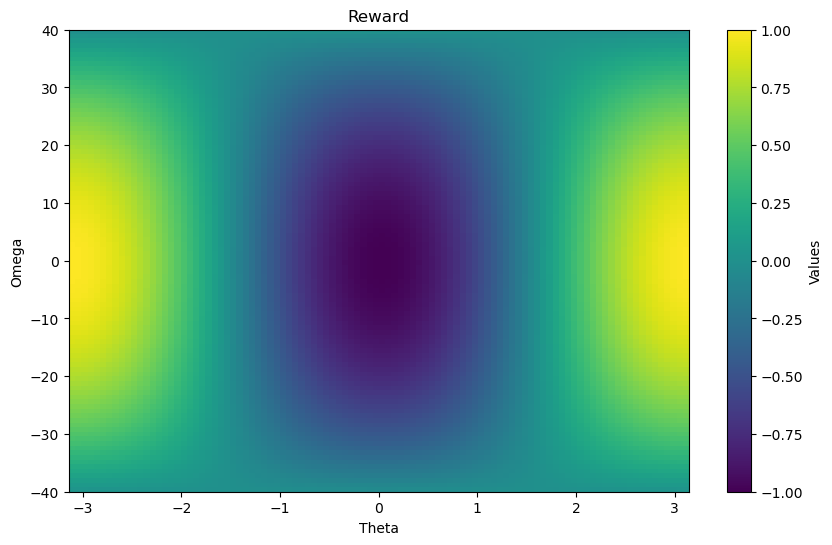

In [166]:
unwrap = lambda theta: \
    -np.cos(theta)

#reward_custom1 = lambda self: \
#    unwrap(self.th) - ((self.omega/40)**2)*unwrap(self.th)  + ((self.omega)*(self.th %(2*math.pi) - math.pi) > 0)

reward_custom = lambda obs: \
    unwrap(obs[0]) - unwrap(obs[0]) *(obs[1]/40)**2
    

thetas = (np.array(range(100))/100)*math.pi*2 - math.pi
omegas = (np.array(range(100))/100)*80 - 40

data = np.zeros([100,100])

for i in range(100): 
    for j in range(100):
        data[j,i] = reward_custom((thetas[i],omegas[j]))

# Create non-uniform grid

plt.figure(figsize=(10, 6))
plt.imshow(data, extent=[-math.pi, math.pi, -40, 40], \
           aspect='auto', cmap='viridis')
plt.colorbar(label='Values')    
plt.xlabel('Theta')
plt.ylabel('Omega')
plt.title('Reward')
plt.show()

# Classes and fucntions

In [148]:
class ActorCritic(nn.Module):
    def __init__(self, order, actor_layer_sizes, critic_layer_sizes):
        super(ActorCritic, self).__init__()
        #The observation and action space are continous
        #There are 2 inputs, theta and omega
        self.order = order
        self.num_states = 2*self.order
        self.num_actions = 1

        self.actor_layer_sizes = actor_layer_sizes
        self.critic_layer_sizes = critic_layer_sizes

        self.num_actor_layers = len(self.actor_layer_sizes)
        self.num_critic_layers = len(self.critic_layer_sizes)
        
        #self.alay = [None for x in range(self.num_actor_layers)]
        self.x = [np.zeros(x) for x in self.actor_layer_sizes]
        #self.clay = [None for x in range(self.num_critic_layers)]
        self.o = [np.zeros(x) for x in self.critic_layer_sizes]

        self.alay = nn.ModuleDict()
        self.clay = nn.ModuleDict()

        self.sigma_u = nn.Parameter(torch.ones(1))
        self.actor_result = 0
        #self.register_parameter('sigma_u', nn.Parameter(torch.ones(1)))

        for i in range(self.num_actor_layers):
            #self.x[i] = np.zeros((self.actor_layer_sizes[i]))
            if i==0: self.alay[f'{i}'] = nn.Linear(self.num_states,self.actor_layer_sizes[i]).float()
            else:    self.alay[f'{i}'] = nn.Linear(self.actor_layer_sizes[i-1],self.actor_layer_sizes[i]).float()

        for i in range(self.num_critic_layers):
            #self.o[i] = np.zeros((self.num_critic_layers[i]))
            if i==0: self.clay[f'{i}'] = nn.Linear(2,self.critic_layer_sizes[i]).float()
            else:    self.clay[f'{i}'] = nn.Linear(self.critic_layer_sizes[i-1],self.critic_layer_sizes[i]).float()


        self.pi_p = lambda data: actor_crit.actor(torch.tensor(data,dtype=torch.float32)).numpy()[0,0]
        self.pi_d = lambda data: actor_crit.deterministic_actor(torch.tensor(data,dtype=torch.float32)).numpy()[0,0]

    def actor(self, state):
        #state has shape (Nbatch, Nobs)
        #state = state[:,None]

        for i in range(self.num_actor_layers):
            if i==0: self.x[i] = torch.sigmoid(self.alay[f'{i}'](state))
            else:    self.x[i] = torch.sigmoid(self.alay[f'{i}'](self.x[i-1]))

        u = self.x[self.num_actor_layers-1] #pass through second layer which results in a shape (N,1) and convert it back to (N,)
        #u = u - torch.max(u) #for additional numerical stability
        
        #u = u.numpy()[0,0]
        #u = self.x[self.num_actor_layers-1,0] #pass through second layer which results in a shape (N,1) and convert it back to (N,)
        #u = u - torch.max(u,dim=1,keepdim=True)[0] #for additional numerical stability

        #return clip(np.random.normal(u,sigma_u),-3,3)
        #if unwrapped: return u
        self.actor_result = clip(u,-3,3)
        return clip(torch.randn(1)*self.sigma_u + u,-3,3)


    def deterministic_actor(self, state):
        #state has shape (Nbatch, Nobs)
        #state = state[:,None]

        for i in range(self.num_actor_layers):
            if i==0: self.x[i] = torch.sigmoid(self.alay[f'{i}'](state))
            else:    self.x[i] = torch.sigmoid(self.alay[f'{i}'](self.x[i-1]))

        u = self.x[self.num_actor_layers-1]
        #u = u - torch.max(u) #for additional numerical stability
        #u = u.numpy()[0,0]
        self.actor_result = clip(u,-3,3)
        return self.actor_result

    def critic(self, state):
        #state has shape (Nbatch, Nobs)
        state = state[:,None]

        for i in range(self.num_critic_layers):
            if i==0: self.o[i] = torch.sigmoid(self.clay[f'{i}'](state))
            else:    self.o[i] = torch.sigmoid(self.clay[f'{i}'](self.o[i-1]))

        #print(self.o[self.num_critic_layers-1])
        
        #v = self.o[self.num_critic_layers-1,0] #pass through second layer which results in a shape (N,1) and convert it back to (N,)
        v = self.o[self.num_critic_layers-1] #pass through second layer which results in a shape (N,1) and convert it back to (N,)

        return torch.flatten(v)

    def forward(self, state):
        #state has shape (Nbatch, Nobs)
        return self.critic(state), self.actor(state)

    def state_prep(self, data, time):
        time += 1
        entries = np.min([time,self.order])
        state = np.zeros((self.order,2))
        state[(self.order-entries):self.order,:] = data[(time-entries):time,:]
        #return np.reshape(state,shape=(1,self.num_states))
        return state.reshape(1,self.num_states)
        
    
def numpy_wrapper(function):
    return lambda data, arguments: function(torch.tensor(data[None,:],dtype=torch.float32), arguments)#.numpy()

def clip(input, low_bound, high_bound):
    return (input<low_bound)*low_bound + (input>high_bound)*high_bound + (input>low_bound)*(input<high_bound)*input

def load_input(u,y,batches=1,order=1):
    n = u.shape[0]
    N = int(n/batches)
    ux = np.concat(([0],u),axis=0)
    yx = np.concat(([0],y),axis=0)

    ux_temp = np.zeros([n,order])
    yx_temp = np.zeros([n,order])

    for i in range(batches):
        ux_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(u[i*N:((i+1)*N)])[:,0:order]
        yx_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(y[i*N:((i+1)*N)])[:,0:order]

    ux = np.tril(ux_temp,k=-1)[0:n,0:order]
    yx = np.tril(yx_temp,k=-1)[0:n,0:order]
    
    return np.concat((ux,yx),axis=1)
    


In [149]:
def rollout(actor_crit, env, N_rollout=10_000, deterministic=False, eval_mode=False, render=False, verbose=False): 
    #save the following (use .append)
    num_states = actor_crit.num_states

    Actions =  np.zeros(N_rollout+1) #hold an array of (u_t)
    Means =  np.zeros(N_rollout+1)
    Rewards =  np.zeros(N_rollout+1) #hold an array of (r_{t+1})
    Terminal =  np.zeros(N_rollout+1) #hold an array of (terminal_{t+1})
    Observations = np.zeros((N_rollout+1,2))
    

    with torch.no_grad():
        obs_init, info = env.reset() 
        Observations[0,:] = obs_init
        Rewards[0] = reward_custom(obs_init)
        rewards_acc = 0

        for i in (range(N_rollout)): 
            
            state = actor_crit.state_prep(Observations,i)
            if eval_mode==True: 
                action = actor_crit.pi_d(state)
                Means[i+1] = action
            if eval_mode==False: 
                action = actor_crit.pi_p(state)
                Means[i+1] = actor_crit.actor_result
            if verbose: print(state, action)

            obs_next, reward, terminated, truncated, info = env.step(action)
            reward = reward_custom(obs_next)

            Actions[i+1] = action
            Terminal[i+1] = terminated
            Rewards[i+1] = reward
            Observations[i+1,:] = obs_next
            rewards_acc += reward

            if render: env.render()
            
            #if terminated or truncated: 
            #    obs, info = env.reset() 
            #else:
            #    obs = obs_next
                
    #error checking:
    #assert len(Start_state)==len(Actions)==len(Rewards)==len(End_state)==len(Terminal), f'error in lengths: {len(Start_state)}=={len(Actions)}=={len(Rewards)}=={len(End_state)}=={len(Terminal)}'
    assert len(Actions)==len(Rewards)==len(Observations)==len(Terminal), f'error in lengths'
    
    if eval_mode==False: return Observations, Actions, Means, Rewards/N_rollout, Terminal.astype(int)
    else: return rewards_acc/N_rollout, Means



In [150]:
def A2C_rollout(actor_crit, optimizer, env, alpha_actor=0.5, alpha_entropy=0.5, gamma=0.98, \
                N_iterations=21, N_rollout=2000, batch_size=32):
    rewards_hist = np.zeros(N_iterations)
    nums = int(N_rollout/batch_size)
    loss_hist = np.zeros(N_iterations*nums+1)
    sigma_hist = np.zeros(N_iterations)
    for iteration in tqdm(range(N_iterations)):
            #print(f'rollout iteration {iteration}')
            
            #2. rollout 
            #Start_state, Actions, Rewards, End_state, Terminal = rollout(actor_crit, env, N_rollout=N_rollout)
            Observations, Actions, Means, Rewards, Terminal = rollout(actor_crit,env,N_rollout=N_rollout, eval_mode=False, render=False, verbose=False)
            rewards_hist[iteration] = np.mean(Rewards)
            
            #Data conversion, no changes required
            convert = lambda x: [torch.tensor(xi,dtype=torch.float32) for xi in x]
            Actions, Observations, Means, Rewards, Terminal = convert([Actions, Observations, Means, Rewards, Terminal])
            #Actions = Actions.astype(int)

            p_const = 0.5*math.log10(2 * math.pi)

            for i in range(batch_size,len(Observations),batch_size): 
                    Observations_batch, Actions_batch, Means_batch, Rewards_batch, Terminal_batch = \
                    [d[i-batch_size:i] for d in [Observations, Actions, Means, Rewards, Terminal]]
                    Observations_next_batch = Observations[i-batch_size+1:i+1]

                    
                    #Advantage:
                    Vnow = actor_crit.critic(Observations_batch)
                    Vnext = actor_crit.critic(Observations_next_batch)
                
                    A = Rewards_batch + Vnext*gamma*(1-Terminal_batch) - Vnow
                    
                    # action_index = np.stack((np.arange(batch_size),Actions_batch),axis=0) #to filter actions
                    #logp = actor_crit.actor(actor_crit.state_prep(Observations_batch,time=i))
                    #logp_cur = logp[np.arange(batch_size), Actions_batch]
                    #p = torch.exp(logp)
                    #p_cur = torch.exp(logp_cur)

                    logp = -0.5 * ((Actions_batch - Means_batch) / actor_crit.sigma_u) ** 2 - 0.5*torch.log(actor_crit.sigma_u) - p_const
                    p = torch.exp(logp)
                    
                    L_value_function = torch.mean(A**2)
                    #L_policy = torch.mean(-A.detach()*logp_cur,axis=0)
                    #L_entropy = torch.mean(p_cur*logp_cur,axis=0).sum()

                    L_policy = alpha_actor*torch.mean(-A.detach()*logp,axis=0)
                    #L_entropy = alpha_entropy*torch.mean(p*logp,axis=0).sum()
                    #L_entropy = torch.log10(torch.max(actor_crit.sigma_u,torch.Tensor([0.1])))
                    L_entropy = -alpha_entropy*torch.log(actor_crit.sigma_u)

                    Loss = L_value_function + L_policy + L_entropy

                    loss_hist[iteration*nums + int(i/batch_size)] = Loss

                    optimizer.zero_grad()
                    Loss.backward()
                    optimizer.step()

            sigma_hist[iteration] = (actor_crit.sigma_u).detach().numpy()
    return rewards_hist, sigma_hist, loss_hist

In [151]:
#actor_crit = ActorCritic(1,[64,64,1],[64,64,1])
#
#    #optimizer = torch.optim.Adam(actor_crit.parameters(), lr=0.005) #low learning rate
#
#    optimizer = torch.optim.Adam([
#        {'params': actor_crit.alay.parameters(), 'lr': 0.005},
#        {'params': actor_crit.clay.parameters(), 'lr': 0.005},
#        {'params': actor_crit.sigma_u, 'lr': 0.001},
#    ])

In [152]:
def objective(trial):

    # 2. Suggest values of the hyperparameters using a trial object.
    n_layers1 = trial.suggest_int('actor_layer1_size', 16, 128)
    n_layers2 = trial.suggest_int('actor_layer2_size', 16, 128)

    n_layers3 = trial.suggest_int('critic_layer1_size', 16, 128)
    n_layers4 = trial.suggest_int('critic_layer2_size', 16, 128)

    lr1 = trial.suggest_float("alr", 0.0001, 0.01)
    lr2 = trial.suggest_float("clr", 0.0001, 0.01)
    lr3 = trial.suggest_float("slr", 0.0001, 0.01)

    alpha1 = trial.suggest_float("alpha_actor", 0.1, 1)
    alpha2 = trial.suggest_float("alpha_entropy", 0.01, 1)

    batches = trial.suggest_int('batches', 1, 10)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    actor_crit = ActorCritic(1,[n_layers1,n_layers2,1],[n_layers3,n_layers4,1])

    optimizer = torch.optim.Adam([
        {'params': actor_crit.alay.parameters(), 'lr': lr1},
        {'params': actor_crit.clay.parameters(), 'lr': lr2},
        {'params': actor_crit.sigma_u, 'lr': lr3},
    ])

    rewards_hist, sigma_hist, loss_hist = A2C_rollout(actor_crit, optimizer, env, alpha_actor=alpha1, alpha_entropy=alpha2, gamma=0.99, \
                N_iterations=2000, N_rollout=batches*batch_size, batch_size=batch_size)

    reward_acc, Means = rollout(actor_crit,env,N_rollout=1000, eval_mode=True, render=False, verbose=False)

    return reward_acc

# 3. Create a study object and optimize the objective function.
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(study.best_params)



[I 2026-06-12 00:03:31,360] A new study created in memory with name: no-name-5b883203-f3bc-4263-b539-7d43b0776548
  0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipykernel_34355/2132517718.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_hist[iteration] = (actor_crit.sigma_u).detach().numpy()
100%|██████████| 2000/2000 [03:41<00:00,  9.04it/s]
[I 2026-06-12 00:07:14,935] Trial 0 finished with value: -0.9902424191385704 and parameters: {'actor_layer1_size': 119, 'actor_layer2_size': 21, 'critic_layer1_size': 16, 'critic_layer2_size': 53, 'alr': 0.0003475377917534704, 'clr': 0.007188411030536201, 'slr': 0.008923823041695774, 'alpha_actor': 0.5431260932630734, 'alpha_entropy': 0.1650447739653477, 'batches': 6, 'batch_size': 57}. Best is trial 0 with value: -0.9902424191385704.
100%|██████████| 2000/2000 [01:

{'actor_layer1_size': 102, 'actor_layer2_size': 99, 'critic_layer1_size': 113, 'critic_layer2_size': 75, 'alr': 0.008223933074198527, 'clr': 0.005596427394985912, 'slr': 0.002735439079582806, 'alpha_actor': 0.6954658281486863, 'alpha_entropy': 0.8658750893538301, 'batches': 8, 'batch_size': 56}


In [153]:
#Observations, Actions, Means, Rewards, Terminal = rollout(actor_crit,env,N_rollout=2000, eval_mode=False, render=True, verbose=True)
#print(f'Observations={Observations}')
#print(f'Actions={Actions}')
#print(f'Rewards={Rewards}')
#print(f'Terminal={Terminal}')

#rewards_hist, sigma_hist, loss_hist = A2C_rollout(actor_crit, optimizer, env, alpha_actor=0.5, alpha_entropy=0.01, gamma=0.98, \
#                N_iterations=500, N_rollout=200, batch_size=40)
#
#reward_acc, Means = rollout(actor_crit,env,N_rollout=400, eval_mode=True, render=True, verbose=False)

#plt.plot([rollout(actor_crit,env,N_rollout=20, eval_mode=True, render=False) for i in tqdm(range(20))],'.')
#plt.xlabel("trials")
#plt.ylabel("mean reward per step")

#env.close()



In [154]:
#env.close()
#
#plt.plot(loss_hist)
#plt.xlabel("Iterations")
#plt.ylabel("Loss")
#plt.show()
#
#plt.plot(rewards_hist)
#plt.xlabel("Iterations")
#plt.ylabel("mean reward per rollout per step")
#plt.show()
#
#plt.plot(sigma_hist)
#plt.xlabel("Iterations")
#plt.ylabel("Sigma_u")
#plt.show()
#
#plt.plot(Means)
#plt.xlabel("Steps")
#plt.ylabel("Action mean")
#plt.show()